In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

Saving HistoricalQuotes.csv to HistoricalQuotes.csv


In [2]:
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())
print(df.columns)

Dataset loaded successfully!
Shape: (2518, 6)
         Date  Close/Last     Volume      Open      High       Low
0  02/28/2020     $273.36  106721200   $257.26   $278.41   $256.37
1  02/27/2020     $273.52   80151380    $281.1      $286   $272.96
2  02/26/2020     $292.65   49678430   $286.53   $297.88    $286.5
3  02/25/2020     $288.08   57668360   $300.95   $302.53   $286.13
4  02/24/2020     $298.18   55548830   $297.26   $304.18   $289.23
Index(['Date', ' Close/Last', ' Volume', ' Open', ' High', ' Low'], dtype='object')


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Check if 'Date' column exists before processing it
if 'Date' in df.columns:
    # Convert Date to datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Convert Close/Last to numeric
    df["Close/Last"] = (
        df["Close/Last"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .astype(float)
    )

    # Sort by date
    df = df.sort_values("Date")

    # Set Date as index
    df.set_index("Date", inplace=True)
else:
    # If 'Date' is not a column, assume it's already the index.
    # Ensure 'Close/Last' is numeric if it's still a column
    if 'Close/Last' in df.columns:
        df["Close/Last"] = (
            df["Close/Last"]
            .astype(str)
            .str.replace("$", "", regex=False)
            .astype(float)
        )
    # Ensure index is sorted if it's a DatetimeIndex or PeriodIndex
    if isinstance(df.index, (pd.DatetimeIndex, pd.PeriodIndex)):
        df = df.sort_index()

# Ensure the index has frequency information (daily period)
# This part applies regardless of whether 'Date' was a column or already index
if not isinstance(df.index, pd.PeriodIndex) or df.index.freqstr != 'D':
    # Convert to DatetimeIndex first if not already, then to PeriodIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    df.index = df.index.to_period('D')

print(df.head())
print("\nDate range:", df.index.min(), "to", df.index.max())
print("\nMissing values:")
print(df.isnull().sum())

            Close/Last     Volume       Open       High        Low  Difference
Date                                                                          
2010-03-01     29.8557  137312041   $29.3928   $29.9286     $29.35         NaN
2010-03-02     29.8357  141486282     $29.99   $30.1186   $29.6771     -0.0200
2010-03-03     29.9043   92846488   $29.8486   $29.9814   $29.7057      0.0686
2010-03-04     30.1014   89591907   $29.8971   $30.1314   $29.8043      0.1971
2010-03-05     31.2786  224647427   $30.7057   $31.3857   $30.6614      1.1772

Date range: 2010-03-01 to 2020-02-28

Missing values:
Close/Last    0
Volume        0
Open          0
High          0
Low           0
Difference    1
dtype: int64


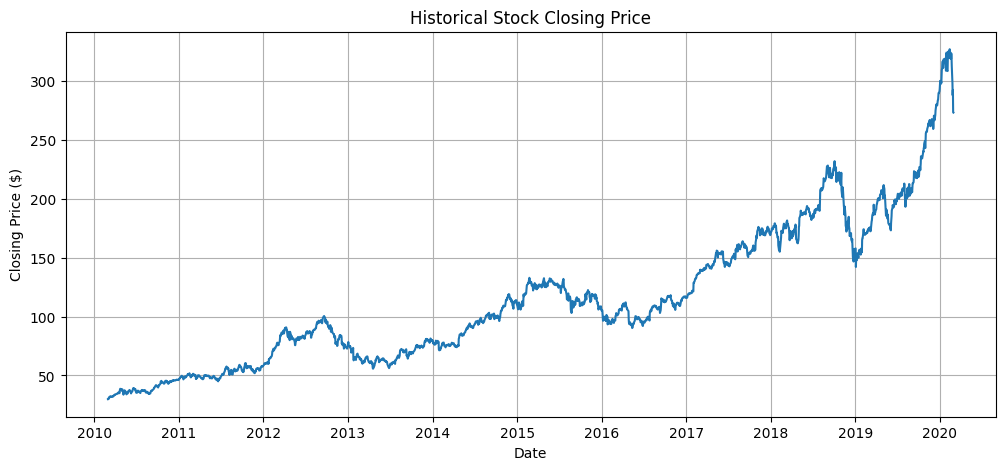

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["Close/Last"])

plt.title("Historical Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.grid(True)

plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

# ADF test
result = adfuller(df["Close/Last"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Result: The time series is stationary.")
else:
    print("Result: The time series is not stationary.")

ADF Statistic: 0.04918130127669495
p-value: 0.9624152269389331
Result: The time series is not stationary.


/tmp/ipykernel_764/157729910.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df["Close/Last"])


In [7]:
# First differencing
df["Difference"] = df["Close/Last"].diff()

# Remove the first NaN value
diff_data = df["Difference"].dropna()

print("Differenced data:")
print(diff_data.head())

Differenced data:
Date
2010-03-02   -0.0200
2010-03-03    0.0686
2010-03-04    0.1971
2010-03-05    1.1772
2010-03-08    0.0185
Name: Difference, dtype: float64


In [8]:
result_diff = adfuller(diff_data)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

if result_diff[1] < 0.05:
    print("Result: The differenced series is stationary.")
else:
    print("Result: The differenced series is not stationary.")

ADF Statistic: -7.225565154664295
p-value: 2.057443713762737e-10
Result: The differenced series is stationary.


/tmp/ipykernel_764/4023696318.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff = adfuller(diff_data)


<Figure size 1200x500 with 0 Axes>

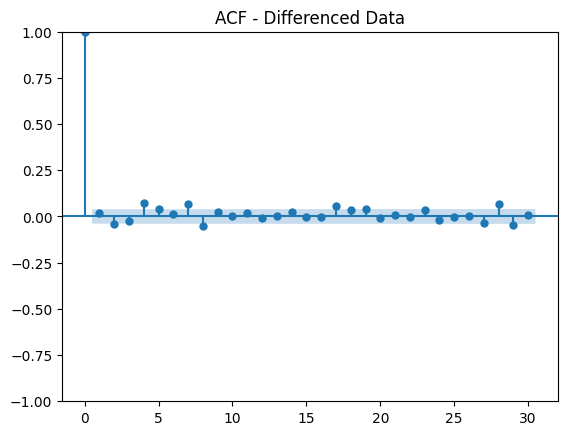

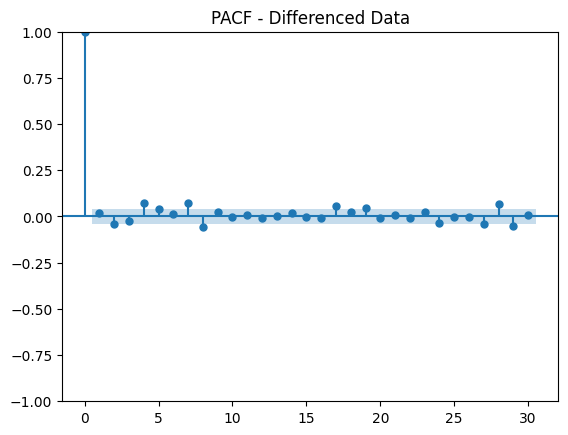

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 5))

plot_acf(diff_data, lags=30)
plt.title("ACF - Differenced Data")
plt.show()

plot_pacf(diff_data, lags=30)
plt.title("PACF - Differenced Data")
plt.show()

In [10]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["Close/Last"], order=(0, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Close/Last   No. Observations:                 2518
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -5437.622
Date:                Wed, 30 Sep 2026   AIC                          10877.244
Time:                        13:29:44   BIC                          10883.075
Sample:                             0   HQIC                         10879.360
                               - 2518                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         4.4054      0.049     89.375      0.000       4.309       4.502
Ljung-Box (L1) (Q):                   0.71   Jarque-Bera (JB):             12810.37
Prob(Q):                              0.40   Pr

In [15]:
# Set daily frequency
df = df.asfreq("D")

# Fill missing values
df["Close/Last"] = df["Close/Last"].ffill()

# Build ARIMA model again
model = ARIMA(df["Close/Last"], order=(0, 1, 0))
model_fit = model.fit()

# Forecast next 30 days
forecast = model_fit.forecast(steps=30)

print("Next 30 days forecast:")
print(forecast)

Next 30 days forecast:
2017-01-21    273.36
2017-01-22    273.36
2017-01-23    273.36
2017-01-24    273.36
2017-01-25    273.36
2017-01-26    273.36
2017-01-27    273.36
2017-01-28    273.36
2017-01-29    273.36
2017-01-30    273.36
2017-01-31    273.36
2017-02-01    273.36
2017-02-02    273.36
2017-02-03    273.36
2017-02-04    273.36
2017-02-05    273.36
2017-02-06    273.36
2017-02-07    273.36
2017-02-08    273.36
2017-02-09    273.36
2017-02-10    273.36
2017-02-11    273.36
2017-02-12    273.36
2017-02-13    273.36
2017-02-14    273.36
2017-02-15    273.36
2017-02-16    273.36
2017-02-17    273.36
2017-02-18    273.36
2017-02-19    273.36
Freq: D, Name: predicted_mean, dtype: float64


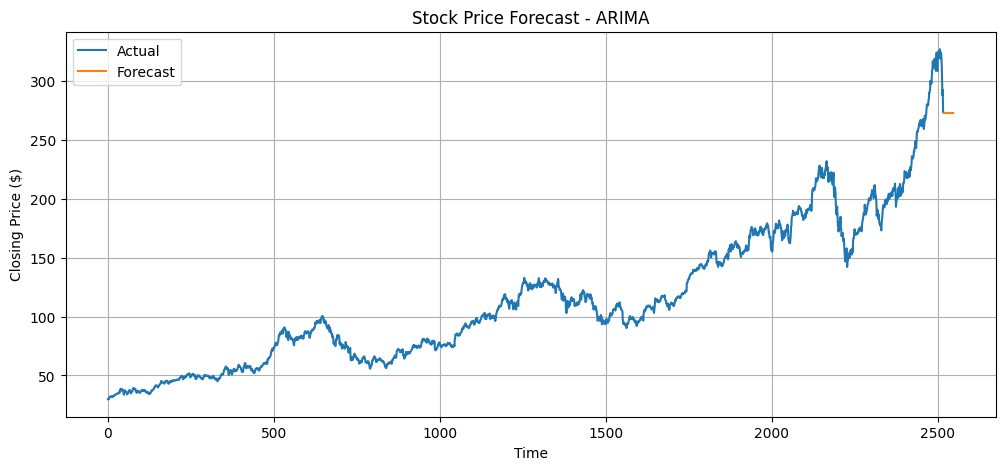

In [17]:
plt.figure(figsize=(12, 5))

# Actual values
plt.plot(df["Close/Last"].values, label="Actual")

# Forecast values
forecast_values = forecast.values
forecast_x = range(len(df), len(df) + len(forecast_values))

plt.plot(forecast_x, forecast_values, label="Forecast")

plt.title("Stock Price Forecast - ARIMA")
plt.xlabel("Time")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
print("===== FORECAST SUMMARY =====")
print("Model: ARIMA(0,1,0)")
print("Forecast period: 30 days")
print("Forecasted price range:")
print("Minimum:", forecast.min())
print("Maximum:", forecast.max())
print("Mean:", forecast.mean())

===== FORECAST SUMMARY =====
Model: ARIMA(0,1,0)
Forecast period: 30 days
Forecasted price range:
Minimum: 273.36
Maximum: 273.36
Mean: 273.35999999999996
